# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [108]:
import numpy as np
import pandas as pd
import re
from PIL import Image
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import urllib.request

## 2. Datos

In [109]:
df = pd.read_csv("./data/train.csv", index_col="laptop_ID") 

### 2.1 Exploración de los datos

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [111]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [112]:
df.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [113]:
df.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


### 2.3 Definir X e y

In [114]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

In [115]:
y.shape

(912,)

In [116]:
X.shape

(912, 11)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [118]:
X_train

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg
...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,1.94kg
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg
770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.18kg


In [119]:
y_train

laptop_ID
1118    2899.00
153     1249.26
275     1958.90
1100    1030.99
131     1396.00
         ...   
578      389.00
996      549.00
770     1859.00
407      306.00
418     1943.00
Name: Price_in_euros, Length: 729, dtype: float64

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [120]:
target = 'Price_in_euros'

In [121]:
# Convertir a numérica Ram en una nueva columna solo con números sin GB. 
# Hacer lo mismo con weight -> hacer nueva columna, numérica, solo con número sin kg

X_train["Weight_kg"] = X_train["Weight"].str.replace("kg", "").astype(float)
X_train["Ram_gb"] = X_train["Ram"].str.replace("GB", "").astype(int)

In [122]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           729 non-null    object 
 1   Product           729 non-null    object 
 2   TypeName          729 non-null    object 
 3   Inches            729 non-null    float64
 4   ScreenResolution  729 non-null    object 
 5   Cpu               729 non-null    object 
 6   Ram               729 non-null    object 
 7   Memory            729 non-null    object 
 8   Gpu               729 non-null    object 
 9   OpSys             729 non-null    object 
 10  Weight            729 non-null    object 
 11  Weight_kg         729 non-null    float64
 12  Ram_gb            729 non-null    int64  
dtypes: float64(2), int64(1), object(10)
memory usage: 79.7+ KB


In [123]:
X_train.head(5)

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Weight_kg,Ram_gb
laptop_ID,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg,3.00,8
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg,2.56,16
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg,1.37,8
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg,1.54,4
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg,2.80,16


-----------------------------------------------------------------------------------------------------------------

<Axes: >

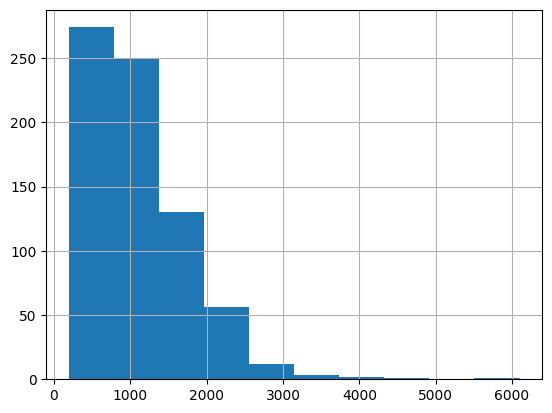

In [124]:
y_train.hist()

In [125]:
features_num = ["Inches", "Weight_kg", "Ram_gb"]

In [126]:
# Tratamiento de Gp y ScreenResolution

X_train["Gpu_nvidia"] = X_train["Gpu"].str.contains("Nvidia", case=False).astype(int)
X_train["Gpu_intel"] = X_train["Gpu"].str.contains("Intel", case=False).astype(int)

resolution = X_train["ScreenResolution"].str.extract(r'(\d{3,4})x(\d{3,4})')
X_train["Screen_width"] = resolution[0].astype(int)
X_train["Screen_height"] = resolution[1].astype(int)

X_train["Total_pixels"] = X_train["Screen_width"] * X_train["Screen_height"]
X_train["Is_IPS"] = X_train["ScreenResolution"].str.contains("IPS", case=False).astype(int)
X_train["Is_Touchscreen"] = X_train["ScreenResolution"].str.contains("Touchscreen", case=False).astype(int)

X_train = X_train.drop("ScreenResolution", axis=1)

In [127]:
# Tratamiento de Cpu

condiciones = [
    X_train["Cpu"].str.contains("i7", case=False),
    X_train["Cpu"].str.contains("i5", case=False),
    X_train["Cpu"].str.contains("i3", case=False)
]

valores = [4, 3, 2]
X_train["Cpu_tier"] = np.select(condiciones, valores, default=1)

X_train["Cpu_speed_ghz"] = X_train["Cpu"].str.extract(r'(\d+\.?\d*)GHz').astype(float)
X_train["Cpu_is_intel"] = X_train["Cpu"].str.contains("Intel", case=False).astype(int)
X_train = X_train.drop("Cpu", axis=1)

In [128]:
# Funciones auxiliares para extraer almacenamiento correctamente --> son de IA 

def sum_memory_gb(mem_str):
    """Suma total del almacenamiento en GB (convierte TB -> 1024 GB)"""
    total = 0
    for part in mem_str.split('+'):
        match = re.search(r'(\d+\.?\d*)', part.strip())
        if match:
            num = float(match.group(1))
            total += num * 1024 if 'TB' in part else num
    return total

def extract_ssd_gb(mem_str):
    """Extrae solo la capacidad SSD/Flash en GB"""
    total = 0
    for part in mem_str.split('+'):
        if 'SSD' in part or 'Flash' in part:
            match = re.search(r'(\d+\.?\d*)', part.strip())
            if match:
                num = float(match.group(1))
                total += num * 1024 if 'TB' in part else num
    return total

X_train["SSD_gb"] = X_train["Memory"].apply(extract_ssd_gb)
X_train["Has_SSD"] = (X_train["SSD_gb"] > 0).astype(int)
X_train["Memory_total_gb"] = X_train["Memory"].apply(sum_memory_gb)

X_train = X_train.drop("Memory", axis=1)

In [129]:
# One-hot encoding de las categóricas 

features_cat = ["Company", "TypeName", "OpSys"]
X_train_enc = pd.get_dummies(X_train, columns=features_cat, drop_first=True)

In [130]:
X_train_enc.head()

,Product,Inches,Ram,Gpu,Weight,Weight_kg,Ram_gb,Gpu_nvidia,Gpu_intel,Screen_width,...,TypeName_Ultrabook,TypeName_Workstation,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,ZBook 17,17.3,8GB,AMD FirePro W6150M,3.0kg,3.00,8,0,0,1920,...,False,True,False,False,False,False,False,False,True,False
153,Inspiron 5577,15.6,16GB,Nvidia GeForce GTX 1050,2.56kg,2.56,16,1,0,1920,...,False,False,False,False,False,False,True,False,False,False
275,MacBook Pro,13.3,8GB,Intel Iris Graphics 550,1.37kg,1.37,8,0,1,2560,...,True,False,False,False,False,False,False,False,False,True
1100,EliteBook 840,14.0,4GB,Intel HD Graphics 520,1.54kg,1.54,4,0,1,1920,...,False,False,False,False,False,False,False,False,True,False
131,Inspiron 5770,17.3,16GB,AMD Radeon 530,2.8kg,2.80,16,0,0,1920,...,False,False,False,False,False,False,True,False,False,False


In [131]:
print(X_train_enc.shape)

(729, 49)


In [132]:
X_train_enc.head()

,Product,Inches,Ram,Gpu,Weight,Weight_kg,Ram_gb,Gpu_nvidia,Gpu_intel,Screen_width,...,TypeName_Ultrabook,TypeName_Workstation,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,ZBook 17,17.3,8GB,AMD FirePro W6150M,3.0kg,3.00,8,0,0,1920,...,False,True,False,False,False,False,False,False,True,False
153,Inspiron 5577,15.6,16GB,Nvidia GeForce GTX 1050,2.56kg,2.56,16,1,0,1920,...,False,False,False,False,False,False,True,False,False,False
275,MacBook Pro,13.3,8GB,Intel Iris Graphics 550,1.37kg,1.37,8,0,1,2560,...,True,False,False,False,False,False,False,False,False,True
1100,EliteBook 840,14.0,4GB,Intel HD Graphics 520,1.54kg,1.54,4,0,1,1920,...,False,False,False,False,False,False,False,False,True,False
131,Inspiron 5770,17.3,16GB,AMD Radeon 530,2.8kg,2.80,16,0,0,1920,...,False,False,False,False,False,False,True,False,False,False


In [133]:
X_train_enc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product               729 non-null    object 
 1   Inches                729 non-null    float64
 2   Ram                   729 non-null    object 
 3   Gpu                   729 non-null    object 
 4   Weight                729 non-null    object 
 5   Weight_kg             729 non-null    float64
 6   Ram_gb                729 non-null    int64  
 7   Gpu_nvidia            729 non-null    int64  
 8   Gpu_intel             729 non-null    int64  
 9   Screen_width          729 non-null    int64  
 10  Screen_height         729 non-null    int64  
 11  Total_pixels          729 non-null    int64  
 12  Is_IPS                729 non-null    int64  
 13  Is_Touchscreen        729 non-null    int64  
 14  Cpu_tier              729 non-null    int64  
 15  Cpu_speed_ghz         729

In [134]:
X_train_enc.drop(["Product", "Weight", "Ram", "Gpu"], axis=1, inplace=True)

In [135]:
X_train_enc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Inches                729 non-null    float64
 1   Weight_kg             729 non-null    float64
 2   Ram_gb                729 non-null    int64  
 3   Gpu_nvidia            729 non-null    int64  
 4   Gpu_intel             729 non-null    int64  
 5   Screen_width          729 non-null    int64  
 6   Screen_height         729 non-null    int64  
 7   Total_pixels          729 non-null    int64  
 8   Is_IPS                729 non-null    int64  
 9   Is_Touchscreen        729 non-null    int64  
 10  Cpu_tier              729 non-null    int64  
 11  Cpu_speed_ghz         729 non-null    float64
 12  Cpu_is_intel          729 non-null    int64  
 13  SSD_gb                729 non-null    float64
 14  Has_SSD               729 non-null    int64  
 15  Memory_total_gb       729

In [136]:
# 1. Tratamiento de Weight, Ram y Gpu en test
X_test["Weight_kg"] = X_test["Weight"].str.replace("kg", "").astype(float)
X_test["Ram_gb"] = X_test["Ram"].str.replace("GB", "").astype(int)
X_test["Gpu_nvidia"] = X_test["Gpu"].str.contains("Nvidia", case=False).astype(int)
X_test["Gpu_intel"] = X_test["Gpu"].str.contains("Intel", case=False).astype(int)

# 2. Tratamiento de Resolution en test 
res_test = X_test["ScreenResolution"].str.extract(r'(\d{3,4})x(\d{3,4})')
X_test["Screen_width"] = res_test[0].astype(int)
X_test["Screen_height"] = res_test[1].astype(int)
X_test["Total_pixels"] = X_test["Screen_width"] * X_test["Screen_height"]
X_test["Is_IPS"] = X_test["ScreenResolution"].str.contains("IPS", case=False).astype(int)
X_test["Is_Touchscreen"] = X_test["ScreenResolution"].str.contains("Touchscreen", case=False).astype(int)

# 3. Tratamiento de Cpu en test
condiciones_test = [
    X_test["Cpu"].str.contains("i7", case=False),
    X_test["Cpu"].str.contains("i5", case=False),
    X_test["Cpu"].str.contains("i3", case=False)
]
X_test["Cpu_tier"] = np.select(condiciones_test, [4, 3, 2], default=1)
X_test["Cpu_speed_ghz"] = X_test["Cpu"].str.extract(r'(\d+\.?\d*)GHz')[0].astype(float)
X_test["Cpu_is_intel"] = X_test["Cpu"].str.contains("Intel", case=False).astype(int)

# 4. Tratamiento de Memory en test (mismas funciones que train)
X_test["SSD_gb"] = X_test["Memory"].apply(extract_ssd_gb)
X_test["Has_SSD"] = (X_test["SSD_gb"] > 0).astype(int)
X_test["Memory_total_gb"] = X_test["Memory"].apply(sum_memory_gb)

# 5. Drop columnas de texto originales
X_test = X_test.drop(columns=["ScreenResolution", "Cpu", "Gpu", "Memory", "Weight", "Ram"])

In [137]:
# One-hot encoding de X_test + alineacion con columnas de train
X_test_enc = pd.get_dummies(X_test.drop("Product", axis=1), columns=features_cat, drop_first=True)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"X_train_enc: {X_train_enc.shape}")
print(f"X_test_enc:  {X_test_enc.shape}")

X_train_enc: (729, 45)
X_test_enc:  (183, 45)


In [138]:
print("Columnas en Train:", X_train_enc.columns.tolist())
print("Columnas en Test:", X_test_enc.columns.tolist())

Columnas en Train: ['Inches', 'Weight_kg', 'Ram_gb', 'Gpu_nvidia', 'Gpu_intel', 'Screen_width', 'Screen_height', 'Total_pixels', 'Is_IPS', 'Is_Touchscreen', 'Cpu_tier', 'Cpu_speed_ghz', 'Cpu_is_intel', 'SSD_gb', 'Has_SSD', 'Memory_total_gb', 'Company_Apple', 'Company_Asus', 'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google', 'Company_HP', 'Company_Lenovo', 'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer', 'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi', 'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation', 'OpSys_Chrome OS', 'OpSys_Linux', 'OpSys_Mac OS X', 'OpSys_No OS', 'OpSys_Windows 10', 'OpSys_Windows 10 S', 'OpSys_Windows 7', 'OpSys_macOS']
Columnas en Test: ['Inches', 'Weight_kg', 'Ram_gb', 'Gpu_nvidia', 'Gpu_intel', 'Screen_width', 'Screen_height', 'Total_pixels', 'Is_IPS', 'Is_Touchscreen', 'Cpu_tier', 'Cpu_speed_ghz', 'Cpu_is_intel', 'SSD_gb', 'Has_SSD', 'Memory

## 4. Modelado

### 4.1 Baseline de modelos


In [139]:
# Modelos baseline. Uso pipeline para todos los que necesitan escalar variables

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree":     DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [140]:
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_enc, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    rmse = -scores
    cv_results[name] = {'RMSE_mean': rmse.mean(), 'RMSE_std': rmse.std()}
    print(f"{name:25s} | {rmse.mean():12.2f} | {rmse.std():12.2f}")

Decision Tree             |       371.68 |        37.38
Random Forest             |       291.11 |        45.67
Gradient Boosting         |       282.33 |        23.33


### 4.3 Optimización (up to you 🫰🏻)

In [141]:
# Validación cruzada de modelos

cv_df = pd.DataFrame(cv_results).T.sort_values('RMSE_mean')

for i, (name, row) in enumerate(cv_df.iterrows(), 1):
    marker = ">>>" if i == 1 else "   "
    print(f"{marker} {i:2d}. {name:25s} | RMSE: {row['RMSE_mean']:.2f} +/- {row['RMSE_std']:.2f}")

best_name = cv_df.index[0]
best_model = models[best_name]

best_model.fit(X_train_enc, y_train)
y_pred_test = best_model.predict(X_test_enc)
rmse = root_mean_squared_error(y_test, y_pred_test)

print(f"\n{'='*55}")
print(f"Mejor modelo: {best_name}")
print(f"RMSE: {rmse:.2f}")

>>>  1. Gradient Boosting         | RMSE: 282.33 +/- 23.33
     2. Random Forest             | RMSE: 291.11 +/- 45.67
     3. Decision Tree             | RMSE: 371.68 +/- 37.38

Mejor modelo: Gradient Boosting
RMSE: 320.23


-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [142]:
X_pred = pd.read_csv("./data/test.csv")
test_ids = X_pred['laptop_ID'] 
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [143]:
X_pred.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
390,421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [144]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         391 non-null    int64  
 1   Company           391 non-null    object 
 2   Product           391 non-null    object 
 3   TypeName          391 non-null    object 
 4   Inches            391 non-null    float64
 5   ScreenResolution  391 non-null    object 
 6   Cpu               391 non-null    object 
 7   Ram               391 non-null    object 
 8   Memory            391 non-null    object 
 9   Gpu               391 non-null    object 
 10  OpSys             391 non-null    object 
 11  Weight            391 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 36.8+ KB


In [145]:
X_pred_clean = X_pred.drop(columns=['laptop_ID']) 

 ## 2. Replicar el procesado para ``test.csv``

In [146]:
X_pred

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg
...,...,...,...,...,...,...,...,...,...,...,...,...
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg


In [147]:
# Aplicamos mismo procesos sobre la features antes de la predicción

# Numéricas

X_pred_clean["Weight_kg"] = X_pred_clean["Weight"].str.replace("kg", "").astype(float)
X_pred_clean["Ram_gb"] = X_pred_clean["Ram"].str.replace("GB", "").astype(int)

# GPU

X_pred_clean["Gpu_nvidia"] = X_pred_clean["Gpu"].str.contains("Nvidia", case=False).astype(int)
X_pred_clean["Gpu_intel"] = X_pred_clean["Gpu"].str.contains("Intel", case=False).astype(int)

# Pantalla

res_pred = X_pred_clean["ScreenResolution"].str.extract(r'(\d{3,4})x(\d{3,4})')
X_pred_clean["Screen_width"] = res_pred[0].astype(int)
X_pred_clean["Screen_height"] = res_pred[1].astype(int)
X_pred_clean["Total_pixels"] = X_pred_clean["Screen_width"] * X_pred_clean["Screen_height"]
X_pred_clean["Is_IPS"] = X_pred_clean["ScreenResolution"].str.contains("IPS", case=False).astype(int)
X_pred_clean["Is_Touchscreen"] = X_pred_clean["ScreenResolution"].str.contains("Touchscreen", case=False).astype(int)

# CPU

condiciones_pred = [
    X_pred_clean["Cpu"].str.contains("i7", case=False),
    X_pred_clean["Cpu"].str.contains("i5", case=False),
    X_pred_clean["Cpu"].str.contains("i3", case=False)
]
X_pred_clean["Cpu_tier"] = np.select(condiciones_pred, [4, 3, 2], default=1)
X_pred_clean["Cpu_speed_ghz"] = X_pred_clean["Cpu"].str.extract(r'(\d+\.?\d*)GHz')[0].astype(float)
X_pred_clean["Cpu_is_intel"] = X_pred_clean["Cpu"].str.contains("Intel", case=False).astype(int)

# Memory 

X_pred_clean["SSD_gb"] = X_pred_clean["Memory"].apply(extract_ssd_gb)
X_pred_clean["Has_SSD"] = (X_pred_clean["SSD_gb"] > 0).astype(int)
X_pred_clean["Memory_total_gb"] = X_pred_clean["Memory"].apply(sum_memory_gb)

# Drop columnas de texto originales

X_pred_clean = X_pred_clean.drop(columns=["Product", "ScreenResolution", "Cpu", "Gpu", "Memory", "Weight", "Ram"])

# One-hot encoding + alineación con columnas de train

X_pred_enc = pd.get_dummies(X_pred_clean, columns=["Company", "TypeName", "OpSys"], drop_first=True)
X_pred_enc = X_pred_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Predicción

predictions_submit = best_model.predict(X_pred_enc)

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [148]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [149]:
sample = pd.read_csv("data/sample_submission.csv")

In [150]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [151]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [152]:
# Crear submission 

submission = pd.DataFrame({
    'laptop_ID': test_ids,
    'Price_in_euros': predictions_submit
})
print(f"Submission shape: {submission.shape}")
submission.head()

Submission shape: (391, 2)


,laptop_ID,Price_in_euros
0,209,1513.257591
1,1281,301.930765
2,1168,365.949219
3,1231,1008.901547
4,1020,940.617538


In [153]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1513.257591
1,1281,301.930765
2,1168,365.949219
3,1231,1008.901547
4,1020,940.617538


In [154]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [155]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [156]:
chequeador(submission)

You're ready to submit!


URLError: <urlopen error [Errno 11001] getaddrinfo failed>